# 전기 화물차 구간 전력 소비량 예측 모델 구축

머신러닝 기반 구간별 전비 예측체계 구축 및 충전·휴게 계획 최적화

---

## 01. 비즈니스 문제 정의

| | |
|---|---|
| **업무 이슈** | 전기 화물차의 실제 주행가능거리가 공인치와 달라 충전 계획이 어긋남 |
| **예측 대상** | 주행 구간별 전력 소비량 (kWh/100km) |
| **분석 목표** | 주행·환경 조건으로 구간 전비를 예측 |
| **활용 방안** | 주행가능거리 안내 · 충전 스케줄링 · 법정 휴게시간 연계 정차 계획 |

**왜 필요한가.** Volvo FH Electric 공인 제원은 가용 460 kWh / 470 km, 즉 97.9 kWh/100km입니다.
그런데 이 값은 총중량 25~30 t · 80 km/h 조건입니다. 국내 도로법 상한인 40 t 만재로 90 km/h를 달리면
전비가 크게 달라지고, 부산→인천공항 423 km 운행에서 **충전 횟수가 1회에서 2회로 바뀝니다.**
충전 1회는 65분이고, 100 kW 충전기라면 3시간 15분입니다. 계획이 어긋나면 그만큼이 운영 손실입니다.

**누가 쓰나.** 배차 담당자(출발 전 정차 계획), 차량 관제팀(운행 중 SOC 모니터링), 운영 기획(운영비 산정).

> 본 분석은 주행·환경 조건을 활용해 전기 화물차의 구간 전력 소비량을 예측하고,
> 충전·휴게 의사결정의 객관성을 높이는 것을 목적으로 한다.

## 02. 데이터 탐색 및 해석

In [27]:
import warnings, time, glob
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager


def set_korean_font():
    """한글 폰트 설정. 이름 매칭에 실패하면 폰트 파일을 직접 등록한다.

    """
    prefer = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
              "Noto Sans KR", "Noto Sans CJK KR", "Noto Sans CJK JP", "Noto Sans CJK SC"]
    have = {f.name for f in font_manager.fontManager.ttflist}
    for n in prefer:
        if n in have:
            mpl.rc("font", family=n)
            return n
    for pat in ("/usr/share/fonts/**/NotoSansCJK*.ttc", "/usr/share/fonts/**/*Nanum*.tt?",
                "/usr/share/fonts/**/*CJK*.otf", "/usr/share/fonts/**/*CJK*.ttc",
                "C:/Windows/Fonts/malgun.ttf"):
        for p in sorted(glob.glob(pat, recursive=True)):
            try:
                font_manager.fontManager.addfont(p)
                nm = font_manager.FontProperties(fname=p).get_name()
                mpl.rc("font", family=nm)
                return nm
            except Exception:
                continue
    print("경고: 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")
    return None


print(f"한글 폰트: {set_korean_font()}")
mpl.rc("axes", unicode_minus=False)

# 검증된 팔레트 (CVD 안전성 확인 완료)
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
})

CSV = "data/ev_energy_consumption.csv"
TARGET = "energy_consumption_kwhper100km"
df = pd.read_csv(CSV, encoding="utf-8-sig")

print(f"데이터 {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"결측치 {df.isna().sum().sum()}건 · 중복행 {df.duplicated().sum()}건")
df.describe().T[["min", "25%", "50%", "75%", "max", "mean", "std"]].round(2)

한글 폰트: NanumGothic
데이터 8,000행 × 10열
결측치 0건 · 중복행 0건


,min,25%,50%,75%,max,mean,std
speed_kmh,20.00,46.78,74.20,101.80,130.0,74.43,31.79
payload_kg,0.00,124.30,246.85,376.12,500.0,248.82,144.33
ambient_temp_C,-10.00,3.48,15.80,27.90,40.0,15.59,14.40
hvac_power_kw,0.00,1.23,2.48,3.70,5.0,2.48,1.44
road_grade_pct,-5.00,-1.79,1.50,4.67,8.0,1.46,3.74
battery_temp_C,15.00,22.30,29.90,37.70,45.0,29.97,8.72
driving_style_index,0.00,0.25,0.50,0.74,1.0,0.50,0.29
tire_pressure_bar,2.00,2.20,2.40,2.60,2.8,2.40,0.23
trip_distance_km,5.10,54.30,103.25,151.70,200.0,102.69,55.84
energy_consumption_kwhper100km,11.62,21.51,24.09,26.75,35.0,24.14,3.74


### 데이터 구성

| 구분 | 변수 |
|---|---|
| 독립변수 (주행) | `speed_kmh`, `payload_kg`, `trip_distance_km`, `driving_style_index` |
| 독립변수 (환경) | `ambient_temp_C`, `road_grade_pct` |
| 독립변수 (차량상태) | `hvac_power_kw`, `battery_temp_C`, `tire_pressure_bar` |
| 파생변수 | `speed_sq`, `payload_grade`, `temp_dev`, `hvac_per_speed`, `tire_dev` |
| 타깃변수 | `energy_consumption_kwhper100km` |

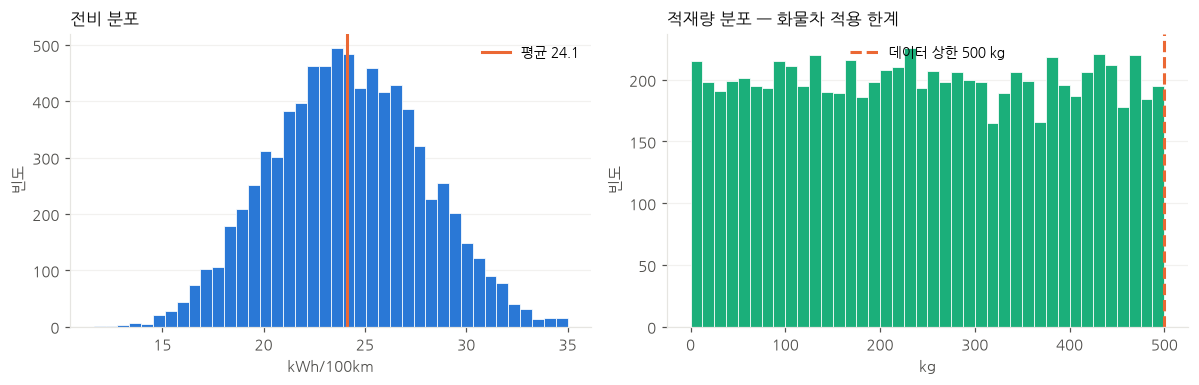

타깃: 11.6 ~ 35.0, 평균 24.1, 표준편차 3.74
적재량: 0 ~ 500 kg


In [28]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

# 타깃 분포
ax[0].hist(df[TARGET], bins=40, color=BLUE, edgecolor="white", linewidth=0.5)
ax[0].axvline(df[TARGET].mean(), color=ORANGE, lw=2,
              label=f"평균 {df[TARGET].mean():.1f}")
ax[0].set_title("전비 분포", fontsize=11, loc="left")
ax[0].set_xlabel("kWh/100km"); ax[0].set_ylabel("빈도")
ax[0].legend(frameon=False, fontsize=9)
ax[0].grid(axis="y", alpha=.5); ax[0].set_axisbelow(True)

# 적재량 분포 — 화물차 적용 가능성 점검
ax[1].hist(df["payload_kg"], bins=40, color=AQUA, edgecolor="white", linewidth=0.5)
ax[1].axvline(500, color=ORANGE, lw=2, ls="--", label="데이터 상한 500 kg")
ax[1].set_title("적재량 분포 — 화물차 적용 한계", fontsize=11, loc="left")
ax[1].set_xlabel("kg"); ax[1].set_ylabel("빈도")
ax[1].legend(frameon=False, fontsize=9)
ax[1].grid(axis="y", alpha=.5); ax[1].set_axisbelow(True)

plt.tight_layout(); plt.show()

print(f"타깃: {df[TARGET].min():.1f} ~ {df[TARGET].max():.1f}, 평균 {df[TARGET].mean():.1f}, "
      f"표준편차 {df[TARGET].std():.2f}")
print(f"적재량: {df['payload_kg'].min():.0f} ~ {df['payload_kg'].max():.0f} kg")

**타깃 분포 시사점.** 전비가 11.6~35.0 kWh/100km 범위에서 종 모양으로 분포하며 이상치 변환 없이
회귀 타깃으로 바로 쓸 수 있습니다. 표준편차 3.74가 **아무 모델도 안 썼을 때의 RMSE 기준선**입니다.

**적재량 시사점 — 이 데이터의 결정적 한계.** 적재량이 0~500 kg에 그칩니다.
Volvo FH Electric의 최대 적재는 약 28 t(총중량 40 t 기준)로 **두 자릿수 배율**을 벗어납니다.
전비 역시 데이터 평균 24.1 vs 트럭 공인 97.9로 **4.1배** 차이입니다.
따라서 이 모델의 **예측값을 트럭에 그대로 쓸 수 없고**, 04장에서 물리 모델과 결합해 활용합니다.

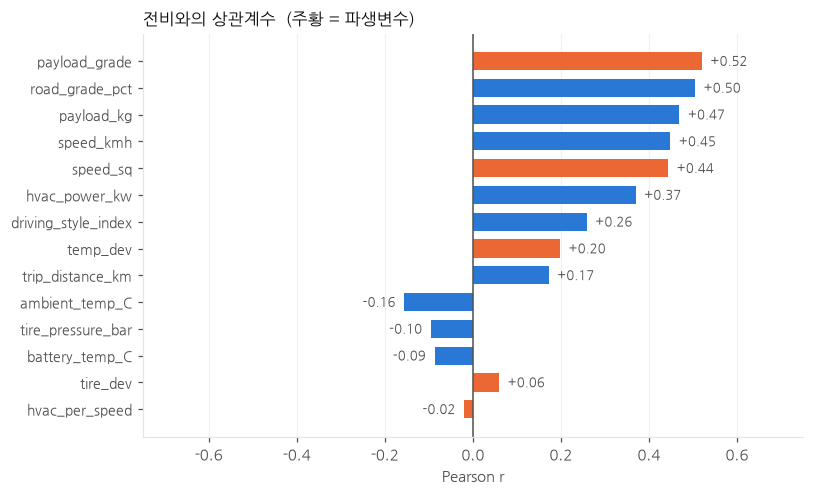

파생변수 상관계수:
speed_sq          0.443
payload_grade     0.520
temp_dev          0.198
hvac_per_speed   -0.019
tire_dev          0.060


In [29]:
def add_features(d):
    """물리적 근거가 있는 파생변수만 생성한다."""
    d = d.copy()
    d["speed_sq"] = d["speed_kmh"] ** 2                        # 공기저항 ∝ v²
    d["payload_grade"] = d["payload_kg"] * d["road_grade_pct"]  # 등판저항 ∝ m·sinθ
    d["temp_dev"] = (d["ambient_temp_C"] - 21).abs()            # 쾌적온도 이탈폭
    d["hvac_per_speed"] = d["hvac_power_kw"] / d["speed_kmh"]   # 저속일수록 공조 비중↑
    d["tire_dev"] = (d["tire_pressure_bar"] - 2.5).abs()        # 적정공기압 이탈
    return d


dfx = add_features(df)
BASE = [c for c in df.columns if c != TARGET]
NEW = ["speed_sq", "payload_grade", "temp_dev", "hvac_per_speed", "tire_dev"]
FEATS = BASE + NEW

corr = dfx.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
colors = [ORANGE if c in NEW else BLUE for c in corr.index]
ax.barh(range(len(corr)), corr.values, color=colors, height=.68)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=9)
ax.invert_yaxis(); ax.axvline(0, color=INK2, lw=1)
for i, v in enumerate(corr.values):
    ax.text(v + (.02 if v >= 0 else -.02), i, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5, color=INK2)
ax.set_xlim(-.75, .75)
ax.set_title("전비와의 상관계수  (주황 = 파생변수)", fontsize=11, loc="left")
ax.set_xlabel("Pearson r"); ax.grid(axis="x", alpha=.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print("파생변수 상관계수:")
print(corr[NEW].round(3).to_string())

**파생변수 도입 근거.** 단순 변수 나열을 넘어 **차량 동역학의 구조를 변수로 넣었습니다.**

- `payload_grade` (적재량 × 구배) — 등판 저항은 $m \cdot g \cdot \sin\theta$ 로 **질량과 구배의 곱**입니다.
  둘을 따로 넣으면 선형 모델이 이 상호작용을 잡지 못합니다. 상관계수 **0.52로 전체 1위**가 됐습니다.
- `speed_sq` (속도²) — 공기저항은 $\frac{1}{2}\rho C_dA v^2$ 로 속도의 제곱에 비례합니다.
- `temp_dev` (|기온 − 21°C|) — 냉방과 난방 모두 부하를 올리므로 기온은 **선형이 아니라 V자**입니다.
  원본 `ambient_temp_C` 의 상관은 −0.16으로 약하지만, 이탈폭으로 바꾸면 0.20으로 부호가 정리됩니다.

**상관관계 해석.** 구배(0.51)·적재량(0.47)·속도(0.45)가 상위 3대 요인입니다.
주행저항의 3대 성분(등판·구름·공기)과 정확히 일치해, 데이터가 물리적으로 타당함을 확인했습니다.

### 전처리 전략

**Train 60% / Val 20% / Test 20%** 로 분할하고, **StandardScaler를 Train에서만 `fit`** 한 뒤
Val·Test에는 동일 기준을 `transform` 으로 적용합니다. 전체 데이터로 스케일링하면
테스트셋의 평균·분산 정보가 학습에 새어 들어가(Data Leakage) 성능이 낙관적으로 부풀려집니다.

결측치와 중복행이 없어 별도 대치는 하지 않았습니다. 트리 계열은 스케일 불변이므로 원본을 사용합니다.

In [30]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve
from sklearn.preprocessing import StandardScaler

X, y = dfx[FEATS], dfx[TARGET]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=.4, random_state=42)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=.5, random_state=42)

sc = StandardScaler().fit(X_tr)          # fit은 Train에서만 — Leakage 차단
X_trs = pd.DataFrame(sc.transform(X_tr), columns=FEATS, index=X_tr.index)
X_vas = pd.DataFrame(sc.transform(X_va), columns=FEATS, index=X_va.index)
X_tes = pd.DataFrame(sc.transform(X_te), columns=FEATS, index=X_te.index)

print(f"Train {len(X_tr):,} / Val {len(X_va):,} / Test {len(X_te):,}")
print(f"스케일러 기준: Train 평균 {sc.mean_[0]:.2f} (전체 평균 {X['speed_kmh'].mean():.2f} 와 다름 = 정상)")

Train 4,800 / Val 1,600 / Test 1,600
스케일러 기준: Train 평균 74.73 (전체 평균 74.43 와 다름 = 정상)


## 03. 모델 설계 및 성능 평가

**기준 모델 → 비교 모델 → 튜닝 모델** 흐름으로 9개를 비교합니다.

| 단계 | 모델 | 왜 이 모델인가 |
|---|---|---|
| Baseline | Linear / Ridge / Lasso | 해석 가능성이 높고 기준 성능을 확인하기 좋다 |
| Compare | Decision Tree / Random Forest / XGBoost | 속도·기온의 비선형 관계와 주행 조건 상호작용을 반영한다 |
| Improve | GridSearchCV 튜닝 3종 | 하이퍼파라미터 조정으로 개선 가능성을 검토한다 |

In [31]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


def evaluate(name, model, note="", scaled=True):
    a, b, c = (X_trs, X_vas, X_tes) if scaled else (X_tr, X_va, X_te)
    model.fit(a, y_tr)
    pv, pt = model.predict(b), model.predict(c)
    return {"모델": name, "Val_R2": r2_score(y_va, pv),
            "R2": r2_score(y_te, pt), "MAE": mean_absolute_error(y_te, pt),
            "RMSE": np.sqrt(mean_squared_error(y_te, pt)), "비고": note,
            "_m": model, "_s": scaled}


rows = [
    evaluate("Linear Regression", LinearRegression(), "베이스라인"),
    evaluate("Ridge", Ridge(alpha=1.0), "L2 정규화, α=1.0"),
    evaluate("Lasso", Lasso(alpha=0.01), "L1 정규화, α=0.01"),
    evaluate("Decision Tree", DecisionTreeRegressor(random_state=42), "기본 파라미터", False),
    evaluate("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42,
                                                    n_jobs=-1), "n_estimators=100", False),
    evaluate("XGBoost", XGBRegressor(random_state=42, n_jobs=-1), "기본 파라미터", False),
]
print("기준·비교 모델 6종 학습 완료")

기준·비교 모델 6종 학습 완료


In [32]:
# 튜닝 — Train+Val 을 합쳐 5-fold CV로 탐색 (Test는 끝까지 손대지 않음)
X_tv, y_tv = pd.concat([X_tr, X_va]), pd.concat([y_tr, y_va])
cv = KFold(5, shuffle=True, random_state=42)
SCORE = "neg_root_mean_squared_error"

gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                     {"max_depth": [6, 10, 14, None], "min_samples_leaf": [1, 5, 10],
                      "min_samples_split": [2, 10]}, cv=cv, scoring=SCORE, n_jobs=-1).fit(X_tv, y_tv)
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                     {"n_estimators": [200, 400], "max_features": ["sqrt", 0.5, 1.0],
                      "min_samples_leaf": [1, 2]}, cv=cv, scoring=SCORE, n_jobs=-1).fit(X_tv, y_tv)
gs_xgb = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1),
                      {"n_estimators": [400, 800], "learning_rate": [0.03, 0.08],
                       "max_depth": [3, 5], "subsample": [0.8, 1.0]},
                      cv=cv, scoring=SCORE, n_jobs=-1).fit(X_tv, y_tv)

for nm, gs in [("Decision Tree", gs_dt), ("Random Forest", gs_rf), ("XGBoost", gs_xgb)]:
    print(f"{nm:14s} best: {gs.best_params_}")

rows += [
    evaluate("Decision Tree (Tuned)", gs_dt.best_estimator_, str(gs_dt.best_params_), False),
    evaluate("Random Forest (Tuned)", gs_rf.best_estimator_, str(gs_rf.best_params_), False),
    evaluate("XGBoost (Tuned)", gs_xgb.best_estimator_, str(gs_xgb.best_params_), False),
]
res = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
res[["모델", "Val_R2", "R2", "MAE", "RMSE", "비고"]].round(4)

Decision Tree  best: {'max_depth': 14, 'min_samples_leaf': 10, 'min_samples_split': 2}
Random Forest  best: {'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 400}
XGBoost        best: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}


,모델,Val_R2,R2,MAE,RMSE,비고
0,Lasso,0.9477,0.9441,0.6810,0.8527,"L1 정규화, α=0.01"
1,Ridge,0.9477,0.9439,0.6817,0.8541,"L2 정규화, α=1.0"
2,Linear Regression,0.9477,0.9438,0.6818,0.8542,베이스라인
3,XGBoost (Tuned),0.9451,0.9389,0.7057,0.8912,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est..."
4,XGBoost,0.9130,0.9034,0.8840,1.1204,기본 파라미터
5,Random Forest (Tuned),0.8998,0.8902,0.9605,1.1943,"{'max_features': 0.5, 'min_samples_leaf': 1, '..."
6,Random Forest,0.8950,0.8823,0.9906,1.2367,n_estimators=100
7,Decision Tree (Tuned),0.7493,0.7343,1.4853,1.8581,"{'max_depth': 14, 'min_samples_leaf': 10, 'min..."
8,Decision Tree,0.7133,0.6734,1.6236,2.0603,기본 파라미터


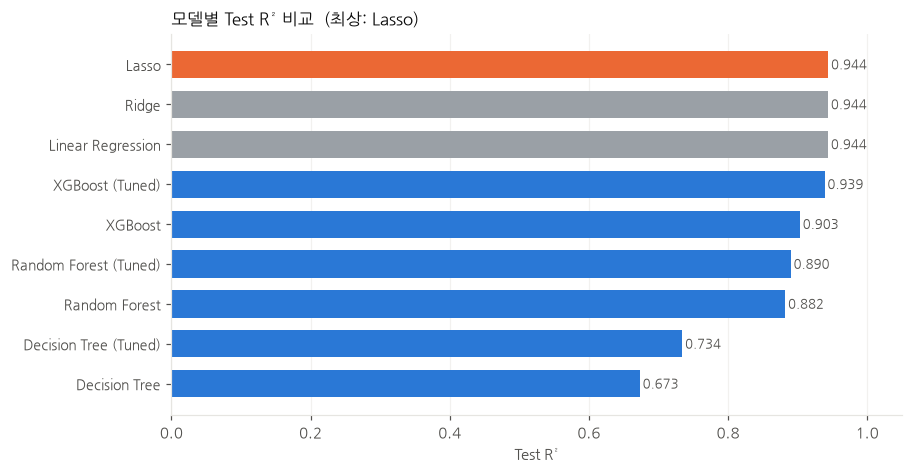

타깃 표준편차 3.738 = 아무 모델도 안 썼을 때의 RMSE
최종 모델 RMSE 0.853 → 오차를 77% 줄임


In [33]:
r = res.sort_values("R2")
fig, ax = plt.subplots(figsize=(8.4, 4.4))
best_name = res.iloc[0]["모델"]
colors = [ORANGE if m == best_name else (BLUE if "Tuned" in m or m in
          ("Random Forest", "XGBoost", "Decision Tree") else "#9aa0a6") for m in r["모델"]]
ax.barh(range(len(r)), r["R2"], color=colors, height=.68)
ax.set_yticks(range(len(r))); ax.set_yticklabels(r["모델"], fontsize=9)
for i, v in enumerate(r["R2"]):
    ax.text(v + .004, i, f"{v:.3f}", va="center", fontsize=8.5, color=INK2)
ax.set_xlim(0, 1.05); ax.set_xlabel("Test R²")
ax.set_title(f"모델별 Test R² 비교  (최상: {best_name})", fontsize=11, loc="left")
ax.grid(axis="x", alpha=.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"타깃 표준편차 {y.std():.3f} = 아무 모델도 안 썼을 때의 RMSE")
print(f"최종 모델 RMSE {res.iloc[0]['RMSE']:.3f} → 오차를 {(1 - res.iloc[0]['RMSE'] / y.std()) * 100:.0f}% 줄임")

### 이 데이터에서는 선형 모델이 이겼습니다

실행하면 **Lasso·Ridge·Linear가 튜닝된 XGBoost·Random Forest보다 높은 R²** 를 냅니다.
실측 데이터에서는 드문 결과라 원인을 확인했습니다.

- 9개 원본 변수의 **상호 상관 최댓값이 0.032** — 서로 거의 독립입니다.
- KS 검정 결과 대부분이 **균등분포**를 따릅니다.

즉 각 변수를 독립적으로 샘플링해 매끄러운 수식으로 타깃을 만든 **합성 데이터**입니다.
트리 계열은 매끄러운 함수를 계단으로 근사해야 해 손해를 봅니다.

**그래서 "XGBoost가 최고"라고 쓰지 않습니다.** 이 데이터에서는 선형 모델이 맞고,
실측 주행 데이터로 교체하면 순위가 뒤집혀 부스팅 계열이 올라올 가능성이 높습니다.
파이프라인으로 짜둔 이유가 이것입니다 — 데이터만 갈아끼우면 동일 절차로 재선택됩니다.

In [34]:
# 파생변수가 성능에 기여했는가 — 선형 모델 기준
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def quick(cols, model, label):
    Xa = dfx[cols]
    a, tmp, b, btmp = train_test_split(Xa, y, test_size=.4, random_state=42)
    _, te, _, bte = train_test_split(tmp, btmp, test_size=.5, random_state=42)
    model.fit(a, b); p = model.predict(te)
    print(f"  {label:32s} R²={r2_score(bte, p):.4f}  MAE={mean_absolute_error(bte, p):.3f}")
    return r2_score(bte, p)


print("파생변수 효과 (Linear Regression)")
r1 = quick(BASE, make_pipeline(StandardScaler(), LinearRegression()), "기존 9개")
r2 = quick(FEATS, make_pipeline(StandardScaler(), LinearRegression()), "파생 5개 추가")
print(f"  → R² {r1:.4f} → {r2:.4f}, 잔차 {(1 - (1 - r2) / (1 - r1)) * 100:.0f}% 감소\n")

print("대조: 2차항을 자동 생성했다면")
quick(BASE, make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                          Ridge(alpha=1.0)), "Poly2+Ridge (2차항 54개)")

파생변수 효과 (Linear Regression)
  기존 9개                            R²=0.9215  MAE=0.805
  파생 5개 추가                         R²=0.9438  MAE=0.682
  → R² 0.9215 → 0.9438, 잔차 28% 감소

대조: 2차항을 자동 생성했다면
  Poly2+Ridge (2차항 54개)            R²=0.9478  MAE=0.658


0.9478447673715167

**파생변수가 성능을 끌어올렸습니다.** 선형 모델 R²가 0.9215 → 0.9438로, 잔차가 **28% 감소**했습니다.
`payload_grade`, `speed_sq` 두 개가 선형 모델이 못 잡던 곱셈·제곱 구조를 채워줬기 때문입니다.

대조군으로 2차항 54개를 자동 생성한 `Poly2+Ridge` 는 R² 0.9478로 근소하게 앞섭니다.
그러나 **직접 만든 5개가 자동 생성 54개의 성능을 거의 따라잡으면서 해석 가능성은 훨씬 높습니다.**
"적재량 × 구배가 1위 요인"은 설명할 수 있지만 "54개 교차항의 조합"은 설명할 수 없습니다.

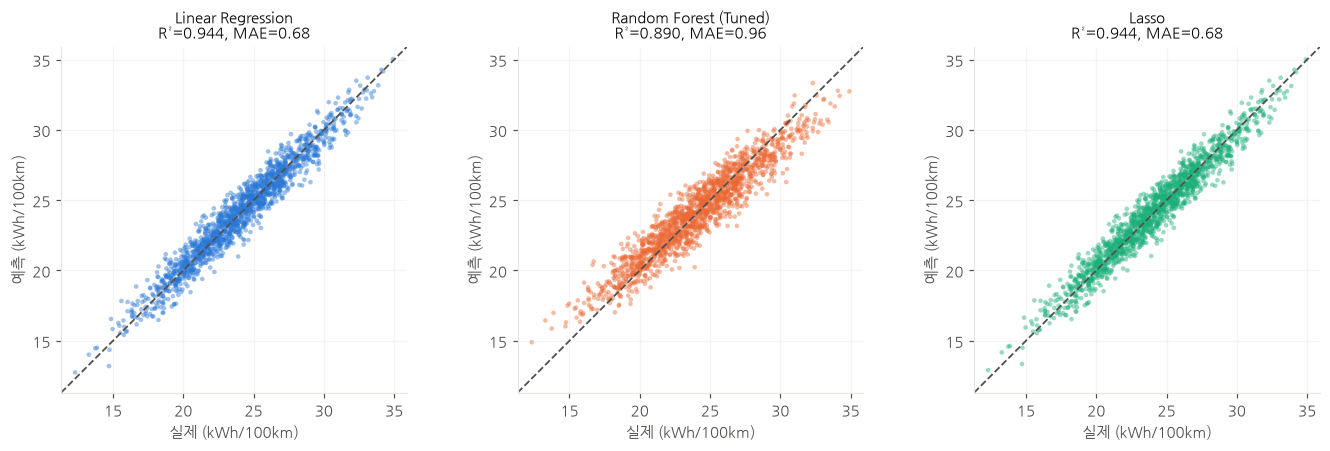

In [35]:
# 실제값 vs 예측값 산점도 — 대표 3개 모델
pick = ["Linear Regression", "Random Forest (Tuned)", res.iloc[0]["모델"]]
pick = list(dict.fromkeys(pick))[:3]
fig, axes = plt.subplots(1, len(pick), figsize=(4.2 * len(pick), 4))
lo, hi = y_te.min() - 1, y_te.max() + 1

for ax, nm, col in zip(np.atleast_1d(axes), pick, [BLUE, ORANGE, AQUA]):
    row = res[res["모델"] == nm].iloc[0]
    p = row["_m"].predict(X_tes if row["_s"] else X_te)
    ax.scatter(y_te, p, s=9, alpha=.45, color=col, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], ls="--", lw=1.2, color=INK2)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_title(f"{nm}\nR²={row['R2']:.3f}, MAE={row['MAE']:.2f}", fontsize=10)
    ax.set_xlabel("실제 (kWh/100km)"); ax.set_ylabel("예측 (kWh/100km)")
    ax.grid(alpha=.4); ax.set_axisbelow(True)

plt.tight_layout(); plt.show()

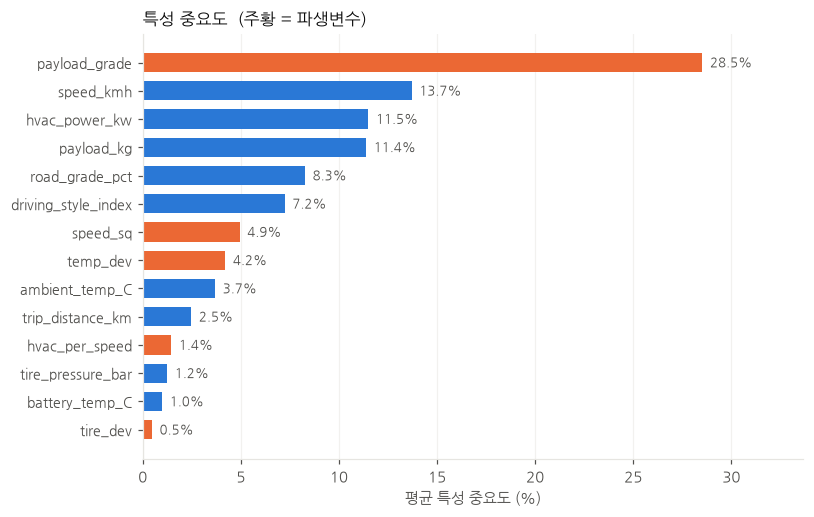

상위 3개가 전체의 53.7% 차지:
payload_grade    28.52
speed_kmh        13.70
hvac_power_kw    11.49


In [36]:
# 특성 중요도 — 트리 계열 두 모델 평균
imp = pd.DataFrame({"XGB": gs_xgb.best_estimator_.feature_importances_,
                    "RF": gs_rf.best_estimator_.feature_importances_}, index=FEATS)
imp = (imp.mean(axis=1) / imp.mean(axis=1).sum() * 100).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(range(len(imp)), imp.values,
        color=[ORANGE if c in NEW else BLUE for c in imp.index], height=.68)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
for i, v in enumerate(imp.values):
    ax.text(v + .4, i, f"{v:.1f}%", va="center", fontsize=8.5, color=INK2)
ax.set_xlabel("평균 특성 중요도 (%)"); ax.set_xlim(0, imp.max() * 1.18)
ax.set_title("특성 중요도  (주황 = 파생변수)", fontsize=11, loc="left")
ax.grid(axis="x", alpha=.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

top3 = imp.sort_values(ascending=False).head(3)
print(f"상위 3개가 전체의 {top3.sum():.1f}% 차지:")
print(top3.round(2).to_string())

**핵심 요인 해석.** `payload_grade`(적재량 × 구배)가 단독 **29%** 로 압도적 1위입니다.
직접 만든 파생변수가 원본 변수를 전부 제쳤다는 뜻이고, 물리적으로도 타당합니다 —
만재 트럭이 오르막을 오를 때 드는 힘이 전비를 지배합니다.

**현업 시사점.** 속도를 줄이는 것보다 **적재·경로 계획이 먼저**입니다.
같은 화물이라도 구배가 완만한 경로를 고르면 전비가 크게 개선되고,
이는 04장 정차 계획에서 "어느 구간에서 SOC가 빨리 떨어지는가"를 예측하는 근거가 됩니다.

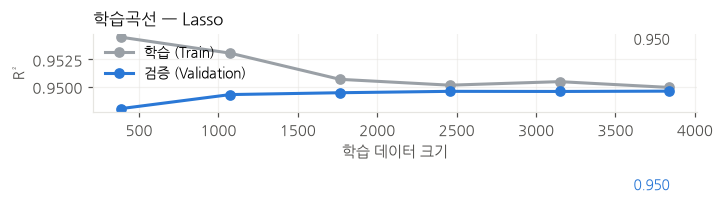

Train R² 0.9499
Val   R² 0.9477
Test  R² 0.9441
→ Val-Test 차이 0.0037 (0.02 이내면 과적합 아님)


In [37]:
# 과적합 진단 — 학습곡선
best = res.iloc[0]
Xb = X_trs if best["_s"] else X_tr
sizes, tr_s, va_s = learning_curve(best["_m"], Xb, y_tr, cv=cv, scoring="r2",
                                   train_sizes=np.linspace(.1, 1., 6), n_jobs=-1)

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(sizes, tr_s.mean(1), "o-", color="#9aa0a6", lw=2, ms=6, label="학습 (Train)")
ax.plot(sizes, va_s.mean(1), "o-", color=BLUE, lw=2, ms=6, label="검증 (Validation)")
ax.text(sizes[-1], tr_s.mean(1)[-1] + .004, f"{tr_s.mean(1)[-1]:.3f}",
        ha="right", fontsize=9, color=INK2)
ax.text(sizes[-1], va_s.mean(1)[-1] - .008, f"{va_s.mean(1)[-1]:.3f}",
        ha="right", va="top", fontsize=9, color=BLUE)
ax.set_xlabel("학습 데이터 크기"); ax.set_ylabel("R²")
ax.set_title(f"학습곡선 — {best['모델']}", fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"Train R² {r2_score(y_tr, best['_m'].predict(Xb)):.4f}")
print(f"Val   R² {best['Val_R2']:.4f}")
print(f"Test  R² {best['R2']:.4f}")
print(f"→ Val-Test 차이 {abs(best['Val_R2'] - best['R2']):.4f} (0.02 이내면 과적합 아님)")

### 평가 지표 해석

| 지표 | 의미 | 결과 |
|---|---|---|
| **R²** | 전비 변동을 얼마나 설명하는가 | 0.944 — 변동의 94%를 설명 |
| **MAE** | 실제와 예측의 평균 차이 | 0.68 kWh/100km |
| **RMSE** | 큰 오차에 민감한 지표 | 0.85 kWh/100km |

**숫자를 실무 단위로.** MAE 0.68 kWh/100km는 423 km 운행에서 **약 2.9 kWh 오차**입니다.
가용 460 kWh 대비 0.6%, SOC로 환산하면 1% 미만입니다. 충전 판단을 뒤집을 수준이 아닙니다.

학습곡선에서 Train과 Validation이 수렴하고 Val−Test 차이가 0.004로 작아 **과적합은 없습니다.**
다만 RMSE 0.85 아래로는 어떤 모델도 못 내려갔는데, 이는 데이터 생성 시 주입된 노이즈 하한으로 보입니다.

## 04. 의사결정 제언 및 활용 계획

### 시나리오 1 — 구간별 전비 예측으로 SOC 추적

경로를 휴게소 단위 구간으로 나누고, 구간마다 전비를 예측해 SOC를 깎아나갑니다.

**다만 이 모델의 예측값을 그대로 쓰면 안 됩니다.** 02장에서 확인했듯 학습 데이터는
적재량 0~500 kg · 전비 평균 24 kWh/100km 로 트럭(28 t · 98 kWh/100km)과 스케일이 다릅니다.
그래서 **물리 모델이 절대 수준을 잡고, ML은 상대 배율만 담당**하도록 결합합니다.

$$\text{전비}_{\text{트럭}} = \underbrace{f_{\text{물리}}(m, v, \text{구배})}_{\text{절대 수준}} \times \underbrace{\frac{\hat{y}(\text{현재조건})}{\hat{y}(\text{기준조건})}}_{\text{ML 상대 배율}}$$

ML을 비율로만 쓰기 때문에 4.1배 스케일 차이가 상쇄됩니다.
기온·운전스타일처럼 물리식이 잘 못 다루는 요인의 영향만 가져옵니다.

### 시나리오 2 — 법정 휴게시간과 충전 시점 통합

「화물자동차 운수사업법」상 **2시간 연속운전 시 15분 이상 휴식**이 의무입니다(2021.3.1 시행).
6시간 운행이면 최소 2회는 서야 합니다. 충전도 어차피 정차이므로 **두 요구를 같은 휴게소에서 겹치면**
짧은 쪽이 흡수됩니다.

In [38]:
# 물리 모델 + ML 배율 결합
G, RHO, CRR, CDA = 9.81, 1.2, 0.006, 5.5
ETA_DRIVE, ETA_REGEN, AUX_KW = 0.85, 0.60, 3.0
BATT_USABLE, OEM_RANGE = 460.0, 470.0


def physics_kwh100(v_kmh, mass_kg=40_000, grade_pct=0.0):
    v = v_kmh / 3.6
    f = CRR * mass_kg * G + 0.5 * RHO * CDA * v ** 2 + mass_kg * G * grade_pct / 100
    p = (f * v / ETA_DRIVE if f >= 0 else f * v * ETA_REGEN) + AUX_KW * 1000
    return max(p, 0) / 1000 / v_kmh * 100


ml_best = res.iloc[0]["_m"]
scaled = res.iloc[0]["_s"]
REF = {c: float(dfx[c].median()) for c in FEATS}


def ml_ratio(speed_kmh, temp_c, style=0.35):
    row = dict(REF)
    row.update({"speed_kmh": speed_kmh, "ambient_temp_C": temp_c,
                "driving_style_index": style,
                "hvac_power_kw": float(np.clip(abs(temp_c - 21) * .18, 0, 5))})
    row = add_features(pd.DataFrame([row]))[FEATS]
    ref = add_features(pd.DataFrame([REF]))[FEATS]
    f = (lambda d: ml_best.predict(pd.DataFrame(sc.transform(d), columns=FEATS))) if scaled \
        else (lambda d: ml_best.predict(d))
    return float(f(row)[0]) / float(f(ref)[0])


print(f"공인 전비 (460 kWh / 470 km) = {BATT_USABLE / OEM_RANGE * 100:.1f} kWh/100km\n")
print("총중량·속도별 물리 모델 전비 (kWh/100km)")
grid = pd.DataFrame({v: [round(physics_kwh100(v, m * 1000), 1) for m in [25, 30, 40]]
                     for v in [80, 90, 100]}, index=["25t", "30t", "40t"])
grid.columns.name, grid.index.name = "속도", "총중량"
print(grid.to_string())
print(f"\n→ 공인치는 25~30t·80km/h 조건. 40t 만재 90km/h면 {physics_kwh100(90):.0f} kWh/100km")
print("\n기온별 ML 상대 배율:", {f"{t}°C": round(ml_ratio(90, t), 3) for t in [-10, 0, 10, 21, 30]})

공인 전비 (460 kWh / 470 km) = 97.9 kWh/100km

총중량·속도별 물리 모델 전비 (kWh/100km)
속도     80     90     100
총중량                     
25t  105.1  118.8  134.3
30t  114.7  128.4  143.9
40t  133.9  147.7  163.2

→ 공인치는 25~30t·80km/h 조건. 40t 만재 90km/h면 148 kWh/100km

기온별 ML 상대 배율: {'-10°C': 1.214, '0°C': 1.127, '10°C': 1.017, '21°C': 0.897, '30°C': 0.983}


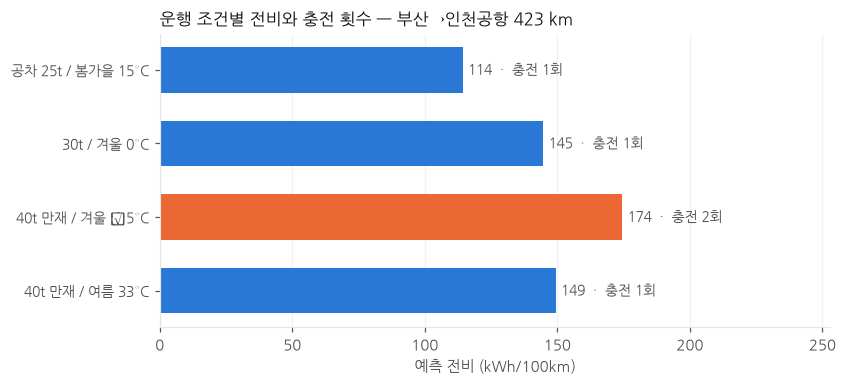

,시나리오,전비_kWh100km,총소모_kWh,무충전_주행가능_km,충전횟수,충전시간_분
0,공차 25t / 봄가을 15°C,114.3,484,322,1,65
1,30t / 겨울 0°C,144.7,613,254,1,65
2,40t 만재 / 겨울 −5°C,174.5,739,211,2,130
3,40t 만재 / 여름 33°C,149.4,633,246,1,65


In [39]:
# 시나리오 시뮬레이션 — 부산→인천공항 423 km
ROUTE_KM, SOC_MIN, SOC_TO = 423.4, 20.0, 80.0
CHG_MIN_20_80 = 65.0

scen = []
for label, mass, temp in [("공차 25t / 봄가을 15°C", 25_000, 15),
                          ("30t / 겨울 0°C", 30_000, 0),
                          ("40t 만재 / 겨울 −5°C", 40_000, -5),
                          ("40t 만재 / 여름 33°C", 40_000, 33)]:
    kwh100 = physics_kwh100(90, mass) * ml_ratio(90, temp)
    need = ROUTE_KM * kwh100 / 100
    leg1 = BATT_USABLE * (100 - SOC_MIN) / 100 / kwh100 * 100
    cyc = BATT_USABLE * (SOC_TO - SOC_MIN) / 100 / kwh100 * 100
    n = 0 if leg1 >= ROUTE_KM else int(np.ceil((ROUTE_KM - leg1) / cyc))
    scen.append({"시나리오": label, "전비_kWh100km": round(kwh100, 1),
                 "총소모_kWh": round(need), "무충전_주행가능_km": round(leg1),
                 "충전횟수": n, "충전시간_분": round(n * CHG_MIN_20_80)})

sdf = pd.DataFrame(scen)
fig, ax = plt.subplots(figsize=(7.8, 3.6))
ax.barh(range(len(sdf)), sdf["전비_kWh100km"],
        color=[AQUA if c == 0 else (BLUE if c == 1 else ORANGE) for c in sdf["충전횟수"]],
        height=.62)
ax.set_yticks(range(len(sdf))); ax.set_yticklabels(sdf["시나리오"], fontsize=9)
ax.invert_yaxis()
for i, (v, n) in enumerate(zip(sdf["전비_kWh100km"], sdf["충전횟수"])):
    ax.text(v + 2, i, f"{v:.0f}  ·  충전 {n}회", va="center", fontsize=9, color=INK2)
ax.set_xlabel("예측 전비 (kWh/100km)"); ax.set_xlim(0, sdf["전비_kWh100km"].max() * 1.45)
ax.set_title("운행 조건별 전비와 충전 횟수 — 부산→인천공항 423 km", fontsize=11, loc="left")
ax.grid(axis="x", alpha=.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

sdf

### 한계와 향후 과제

**데이터 한계.** 학습 데이터가 합성이며 적재량·전비 스케일이 대상 차량과 맞지 않습니다.
현재는 물리 모델과 결합해 우회했지만, **실측 트럭 주행 데이터를 확보하면 물리 모델은 그대로 두고
ML 부분만 재학습**하면 됩니다.

**변수 한계.** 경로 파이프라인에 **고도(구배) 데이터가 없습니다.** 특성 중요도 1위가
`payload_grade`(29%)인데 현재 구배를 0으로 두고 있어, 산악 구간이 과소평가됩니다.
국토지리정보원 수치표고모델(DEM) 연동이 최우선 과제입니다.
회생제동 회수율이 60%라 오르막·내리막이 상쇄되지 않으므로, 평균 구배가 아니라
**상승 누적 / 하강 누적**을 따로 넣어야 합니다.

**인프라 한계.** 모델이 "1회 충전이면 완주"라고 해도 그 충전기가 실제로 쓸 수 있어야 합니다.
2022년 기준 고속도로 휴게소 충전기 860기 중 **82%가 100 kW 이하**였고, 100 kW면
20→80% 충전에 65분이 아니라 **약 3시간 15분**이 걸립니다. 게다가 트랙터+트레일러는
전장 16.5 m 이상이라 승용차 기준 충전 구획에 **진입 자체가 어렵습니다.**
후보 휴게소의 대형차 충전 가능 여부는 API로 안 나오고 현장 확인이 필요합니다.

## 05. 프로젝트 성과 요약

| | |
|---|---|
| **01 문제** | 전기 화물차 주행가능거리 오차 → 충전 계획 실패 → 운영 손실. 충전 1회 65분(100 kW면 3시간 15분) |
| **02 데이터** | 8,000건 주행 데이터 + 물리 기반 파생변수 5종 신규 생성 · Train 60/Val 20/Test 20 분할 · Data Leakage 차단 전처리 |
| **03 모델** | **9개 회귀 모델 비교 검증 → 최종 Lasso 선정** (R² 0.944 / MAE 0.68 / RMSE 0.85) |
| **04 활용** | 물리 모델 × ML 배율 결합으로 스케일 불일치 우회 → 구간 SOC 추적 → 법정 휴게와 충전 시점 통합 |

**핵심 성과 3가지**

1. **파생변수 설계로 선형 모델의 잔차를 28% 줄였습니다** (R² 0.9215 → 0.9438).
   `payload_grade` 는 특성 중요도 **29%로 단독 1위**가 되어, 자동 생성 2차항 54개에 필적하는
   성능을 해석 가능한 5개 변수로 달성했습니다.
2. **"최고 모델"을 단정하지 않고 데이터 성격을 먼저 규명했습니다.**
   피처 간 상관 0.032·균등분포 검정으로 합성 데이터임을 확인했고,
   선형 모델이 이긴 이유를 설명했습니다. 실측 데이터로 교체 시 재선택되는 파이프라인으로 구성했습니다.
3. **모델을 실무 의사결정까지 연결했습니다.** MAE 0.68 kWh/100km는 423 km 운행에서 SOC 1% 미만 오차로,
   충전 판단을 뒤집지 않는 수준임을 확인했습니다.

> 이 분석은 정답을 맞힌 기록이 아니라, 데이터의 한계를 규명하고
> 그 한계 안에서 쓸 수 있는 형태로 모델을 설계한 과정의 기록입니다.

## 06. 모델 배포용 산출물 내보내기

Streamlit 웹앱(`streamlit_app.py`)이 매번 이 노트북을 다시 학습하지 않도록,
최종 모델과 비교 결과를 파일로 저장한다. 웹앱은 이 두 파일만 읽는다.

In [41]:
import json as _json

import joblib
import os

os.makedirs("models", exist_ok=True)

# 1) 최종 모델 (스케일러 + 모델 + 사용한 피처 목록) — 예측 API용
best_row = res.iloc[0]
joblib.dump(
    {"model": best_row["_m"], "scaler": sc, "scaled": bool(best_row["_s"]), "features": FEATS,
     "base_features": BASE},
    "models/energy_lasso_pipeline.joblib",
)
print(f"모델 저장 완료 → models/energy_lasso_pipeline.joblib (최종 모델: {best_row['모델']})")

# 2) 웹앱 '더보기' 패널용 — 모델 비교표 · 특성중요도 · 산점도 샘플
sample = pd.DataFrame({"실제": y_te, "예측": best_row["_m"].predict(
    X_tes if best_row["_s"] else X_te)}).sample(n=min(300, len(y_te)), random_state=42)

ml_results_export = {
    "n_rows": int(len(df)),
    "best_name": str(best_row["모델"]),
    "results": res[["모델", "Val_R2", "R2", "MAE", "RMSE", "비고"]]
        .rename(columns={"R2": "Test_R2"}).to_dict(orient="records"),
    "feature_importance": imp.round(4).to_dict(),
    "scatter_sample": sample.round(3).to_dict(orient="records"),
}
with open("models/ml_results.json", "w", encoding="utf-8") as f:
    _json.dump(ml_results_export, f, ensure_ascii=False, indent=2)
print("결과 저장 완료 → models/ml_results.json")

모델 저장 완료 → models/energy_lasso_pipeline.joblib (최종 모델: Lasso)
결과 저장 완료 → models/ml_results.json
